# German Credit Case Study

## Problem Statement

### Context

To minimize loss from the bank’s perspective, the bank needs a decision rule regarding whom to approve the loan and whom not to. An applicant’s demographic and socio-economic profiles are considered by loan managers before a decision is taken regarding his/her loan application.
In this dataset, each entry represents a person who takes credit from a bank. Each person is classified as a good or bad credit risk according to the set of attributes.


### Objective:
The objective is to build a predictive model on this data to help the bank decide on whether to approve a loan to a prospective applicant.


### Dataset:
- Age (Numeric: Age in years)
- Sex (Categories: male, female)
- Saving accounts (Categories: little, moderate, quite rich, rich)
- Checking account (Categories: little, moderate, rich)
- Credit amount (Numeric: Amount of credit in DM - Deutsche Mark)
- Duration (Numeric: Duration for which the credit is given in months)
- Purpose (Categories: car, furniture/equipment,radio/TV, domestic appliances, repairs, education, business, vacation/others)
- Risk (0 - Person is not at risk, 1 - Person is at risk(defaulter))

In [7]:
# Libraries for Reading and manipulating data

import pandas as pd
import numpy as np

# Library to split data
from sklearn.model_selection import train_test_split

# Libaries to help with data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Removes the limit for the number of displayed columns
pd.set_option("display.max_columns", None)
# Sets the limit for the number of displayed rows
pd.set_option("display.max_rows", 200)


# To build model for prediction
from sklearn.linear_model import LogisticRegression

# To get diferent metric scores
from sklearn.metrics import (
    f1_score,
    accuracy_score,
    recall_score,
    precision_score,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
    precision_recall_curve,
)

# To ignore unnecessary warnings
import warnings
warnings.filterwarnings("ignore")

## Loading the dataset

In [11]:
# Uploading dataset file from local system into Google Colab environment
from google.colab import files
_ = files.upload()

Saving German_Credit-1 (1).xlsx to German_Credit-1 (1).xlsx


In [12]:
data = pd.read_excel("German_Credit.xlsx")

## Data Overview

### View the first and last 5 rows of the dataset.

In [13]:
data.head()

,Age,Sex,Saving accounts,Checking account,Credit amount,Duration,Risk,Purpose
0,67,male,little,little,1169,6,0,radio/TV
1,22,female,little,moderate,5951,48,1,radio/TV
2,49,male,little,little,2096,12,0,education
3,45,male,little,little,7882,42,0,furniture/equipment
4,53,male,little,little,4870,24,1,car


In [14]:
data.tail()

,Age,Sex,Saving accounts,Checking account,Credit amount,Duration,Risk,Purpose
995,31,female,little,little,1736,12,0,furniture/equipment
996,40,male,little,little,3857,30,0,car
997,38,male,little,little,804,12,0,radio/TV
998,23,male,little,little,1845,45,1,radio/TV
999,27,male,moderate,moderate,4576,45,0,car


* The dataset contains information about different applicants.

### Understand the shape of the dataset.

In [15]:
data.shape # The dataset has 1000 rows and 8 columns

(1000, 8)

### Check the data types of the columns for the dataset.

In [16]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Age               1000 non-null   int64 
 1   Sex               1000 non-null   object
 2   Saving accounts   1000 non-null   object
 3   Checking account  1000 non-null   object
 4   Credit amount     1000 non-null   int64 
 5   Duration          1000 non-null   int64 
 6   Risk              1000 non-null   int64 
 7   Purpose           1000 non-null   object
dtypes: int64(4), object(4)
memory usage: 62.6+ KB


- There are total 8 columns and 1,000 observations in the dataset
- We have only three continuous variables - Age, Credit Amount, Risk and Duration.
- All other variables are categorical
- We can see that there are no missing values in the dataset.

### Checking for duplicate values

In [17]:
data.duplicated().sum()

np.int64(0)

- There are no duplicate values in the dataset.

### Checking for missing values

In [18]:
data.isnull().sum()

,0
Age,0
Sex,0
Saving accounts,0
Checking account,0
Credit amount,0
Duration,0
Risk,0
Purpose,0


- There are no missing values in the dataset

### Statistical summary

In [19]:
data.describe().T

,count,mean,std,min,25%,50%,75%,max
Age,1000.0,35.546,11.375469,19.0,27.0,33.0,42.00,75.0
Credit amount,1000.0,3271.258,2822.736876,250.0,1365.5,2319.5,3972.25,18424.0
Duration,1000.0,20.903,12.058814,4.0,12.0,18.0,24.00,72.0
Risk,1000.0,0.300,0.458487,0.0,0.0,0.0,1.00,1.0


**Observations**

- Mean value for the age column is approx 35 and the median is 33. This shows that majority of the customers are under 35 years of age.
- Mean amount of credit is approx 3,271 but it has a wide range with values from 250 to 18,424. We will explore this further in univariate analysis.
- Mean duration for which the credit is given is approx 21 months.

In [20]:
# Making a list of all categorical variables
cat_col = [
    "Sex",
    "Saving accounts",
    "Checking account",
    "Purpose",
    "Risk",
]

# Printing number of count of each unique value in each column
for column in cat_col:
    print(data[column].value_counts())
    print("-" * 40)

Sex
male      690
female    310
Name: count, dtype: int64
----------------------------------------
Saving accounts
little        786
moderate      103
quite rich     63
rich           48
Name: count, dtype: int64
----------------------------------------
Checking account
moderate    472
little      465
rich         63
Name: count, dtype: int64
----------------------------------------
Purpose
car                    337
radio/TV               280
furniture/equipment    181
business                97
education               59
repairs                 22
domestic appliances     12
vacation/others         12
Name: count, dtype: int64
----------------------------------------
Risk
0    700
1    300
Name: count, dtype: int64
----------------------------------------


- We have more male customers as compared to female customers
- We can see that the distribution of classes in the target variable is imbalanced i.e., only 30% observations with defaulters.
- Most of the customers are not at risk.

## Exploratory Data Analysis (EDA)


**Note**: The EDA section has been covered multiple times in the previous case studies. In this case study, we will mainly focus on the model building aspects. We will only be looking at the key observations from EDA. The detailed EDA can be found in the appendix section.

## **Univariate Analysis**

### Age

<Axes: xlabel='Age', ylabel='Count'>

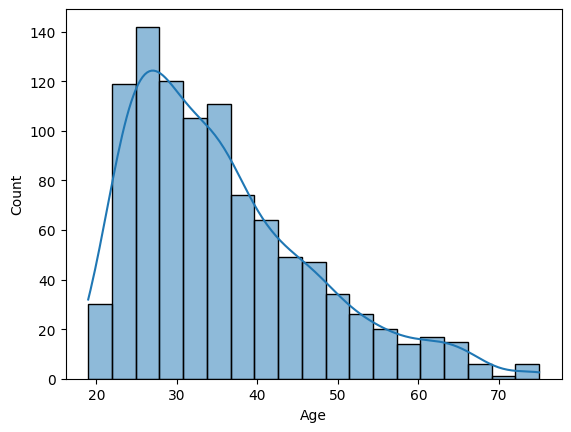

In [21]:
sns.histplot(data=data, x="Age", kde=True)

<Axes: xlabel='Age'>

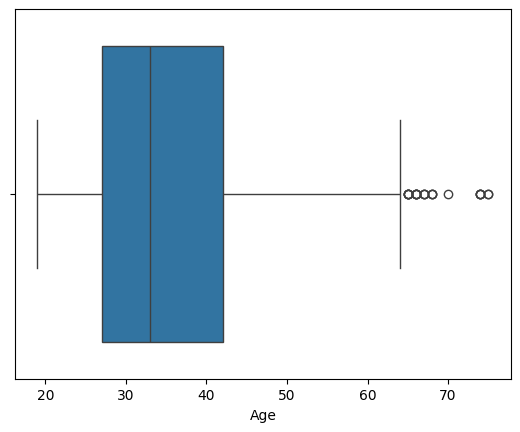

In [22]:
sns.boxplot(data=data, x="Age")

- The distribution of age is right-skewed
- The boxplot shows that there are outliers at the right end
- We will not treat these outliers as they represent the real market trend

### Credit Amount

<Axes: xlabel='Credit amount', ylabel='Count'>

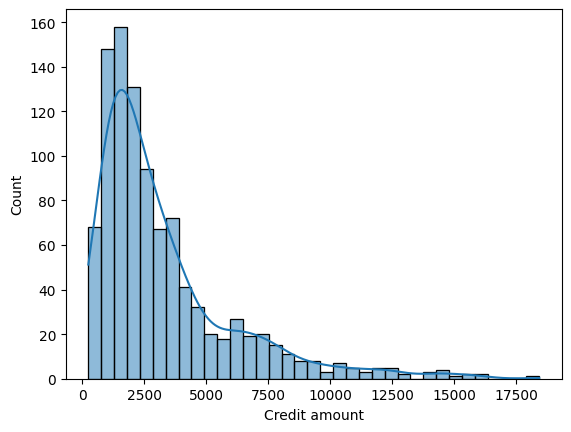

In [27]:
sns.histplot(data=data, x="Credit amount", kde=True)

<Axes: xlabel='Credit amount'>

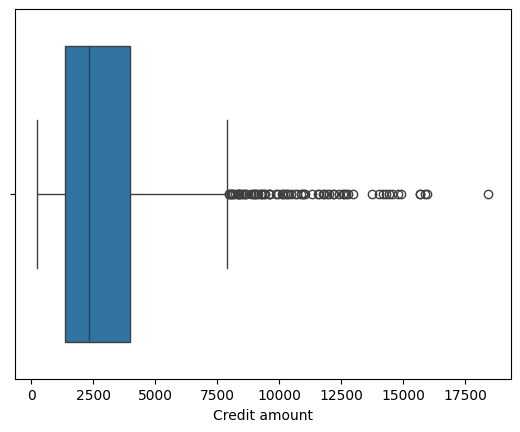

In [28]:
sns.boxplot(data=data, x="Credit amount")

- The distribution of the credit amount is right-skewed
- The boxplot shows that there are outliers at the right end
- We will not treat these outliers as they represent the real market trend

### Risk

<Axes: xlabel='Risk', ylabel='count'>

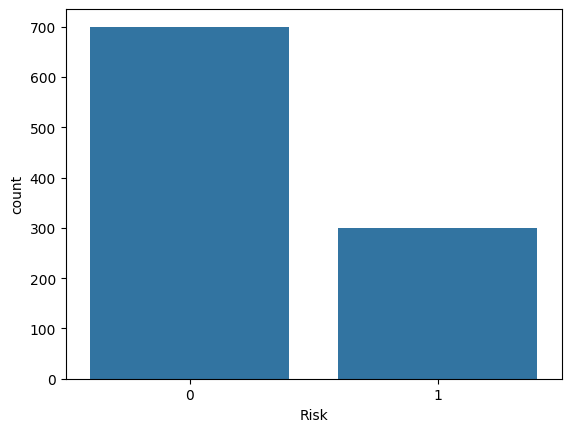

In [29]:
sns.countplot(data=data, x="Risk")

- Good risk customers are more common.
- Bad risk customers form the minority class.
- Dataset is slightly imbalanced.
- Risk feature is the target variable.
- Imbalance should be considered during modeling.

### Duration

<Axes: xlabel='Duration', ylabel='Count'>

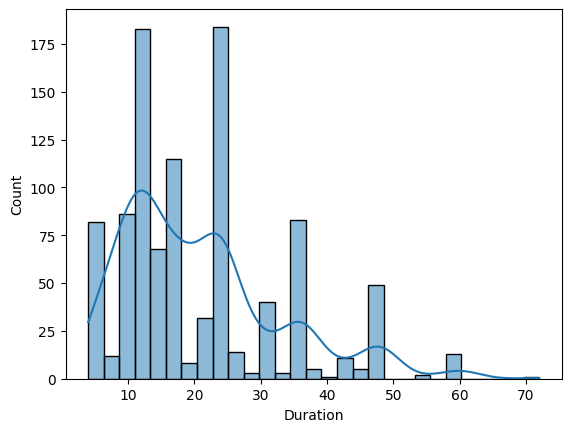

In [30]:
sns.histplot(data=data, x="Duration", kde=True)

<Axes: xlabel='Duration'>

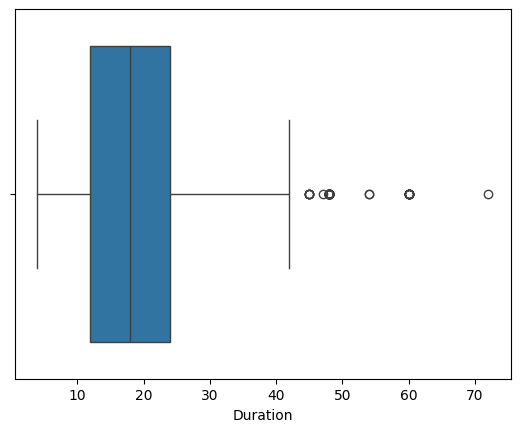

In [31]:
sns.boxplot(data=data, x="Duration")

- Most applicants have shorter loan durations.
- The distribution is positively skewed.
- Few customers have very long repayment durations.
- Longer durations may indicate higher repayment risk.

### Sex

<Axes: xlabel='Sex', ylabel='count'>

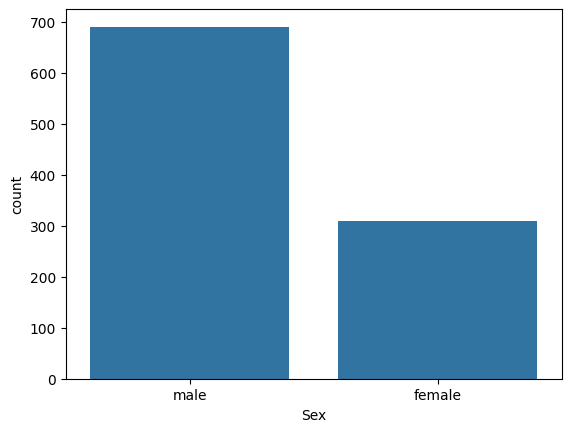

In [32]:
sns.countplot(data=data, x="Sex")

- Male applicants appear more frequently.
- Dataset may have class imbalance for gender.
- Female applicants form a smaller proportion.
- Loan applications are dominated by one gender category.

### Purpose

([0, 1, 2, 3, 4, 5, 6, 7],
 [Text(0, 0, 'radio/TV'),
  Text(1, 0, 'education'),
  Text(2, 0, 'furniture/equipment'),
  Text(3, 0, 'car'),
  Text(4, 0, 'business'),
  Text(5, 0, 'domestic appliances'),
  Text(6, 0, 'repairs'),
  Text(7, 0, 'vacation/others')])

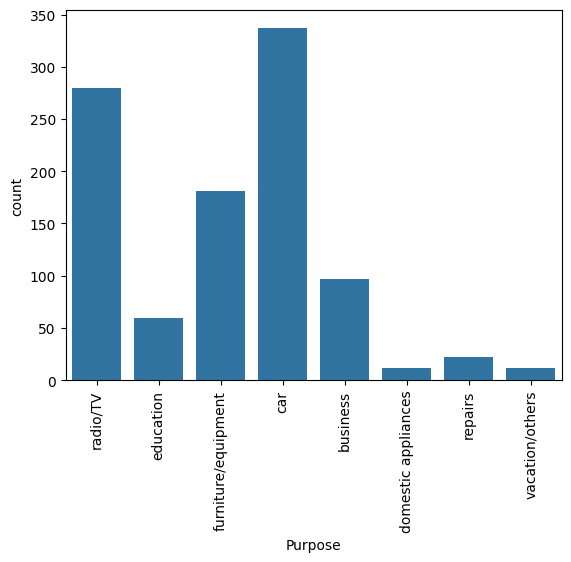

In [37]:
sns.countplot(data=data, x="Purpose")
plt.xticks(rotation=90)

- Car and radio/TV purposes are common.
- Some loan purposes have very few applicants.
- Loan purpose distribution is highly varied.
- Consumer-related loans dominate.
- Certain categories may be linked to higher risk.

### Saving Accounts

<Axes: xlabel='Saving accounts', ylabel='count'>

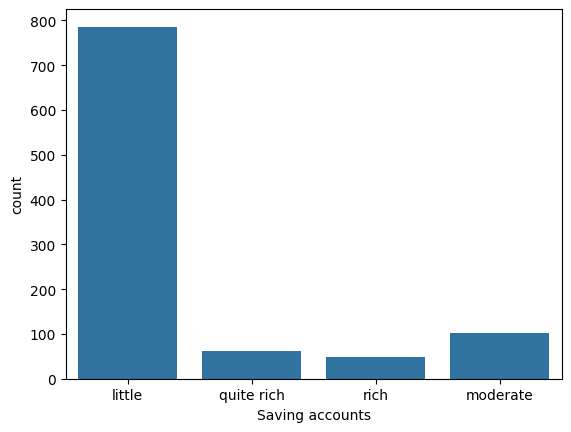

In [38]:
sns.countplot(data=data, x="Saving accounts")

- Many applicants have little or moderate savings.
- Some saving categories have very low counts.
- Higher savings may indicate lower risk.
- Missing values may exist in this feature.
- Savings distribution is uneven.

### Checking Account

<Axes: xlabel='Checking account', ylabel='count'>

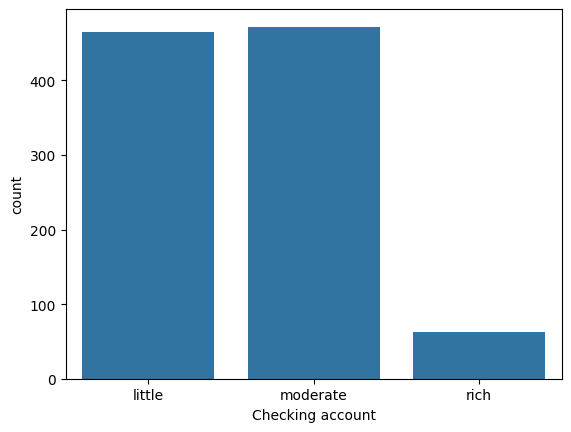

In [39]:
sns.countplot(data=data, x="Checking account")

- Low checking account balances are more common.
- Some categories dominate the distribution.
- Missing values are present.
- Checking balance may relate to creditworthiness.
- Customers with richer balances are fewer.

## **Bivariate Analysis**

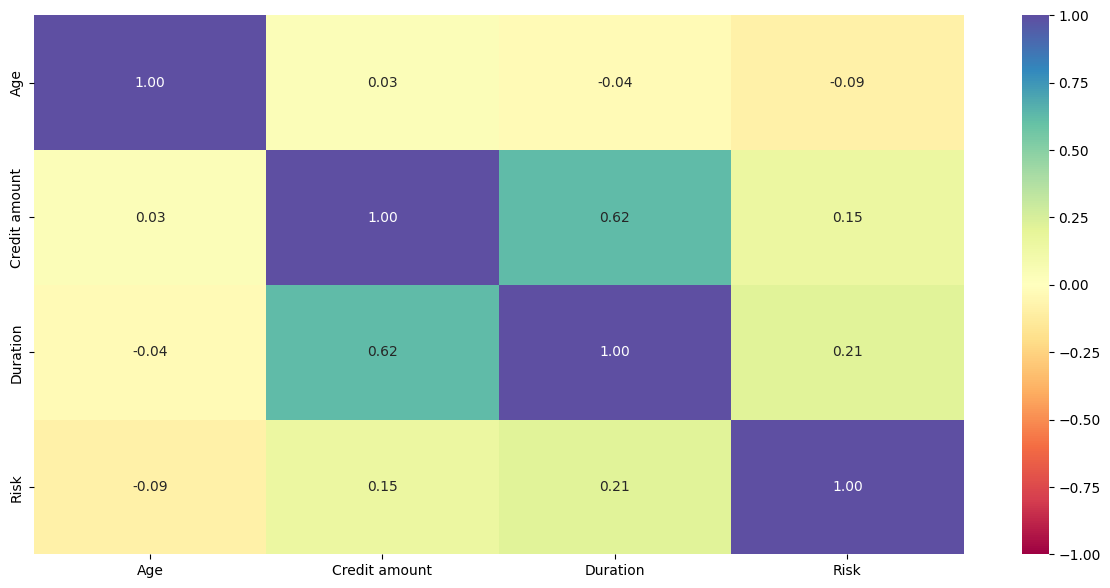

In [78]:
plt.figure(figsize=(15, 7))
sns.heatmap(data.corr(numeric_only=True), annot=True, vmin=-1, vmax=1, fmt=".2f", cmap="Spectral")
plt.show()

- Credit amount and duration have positive correlation which makes sense as customers might take the credit for longer duration if the amount of credit is high.
- Other variables have no significant correlation between them.

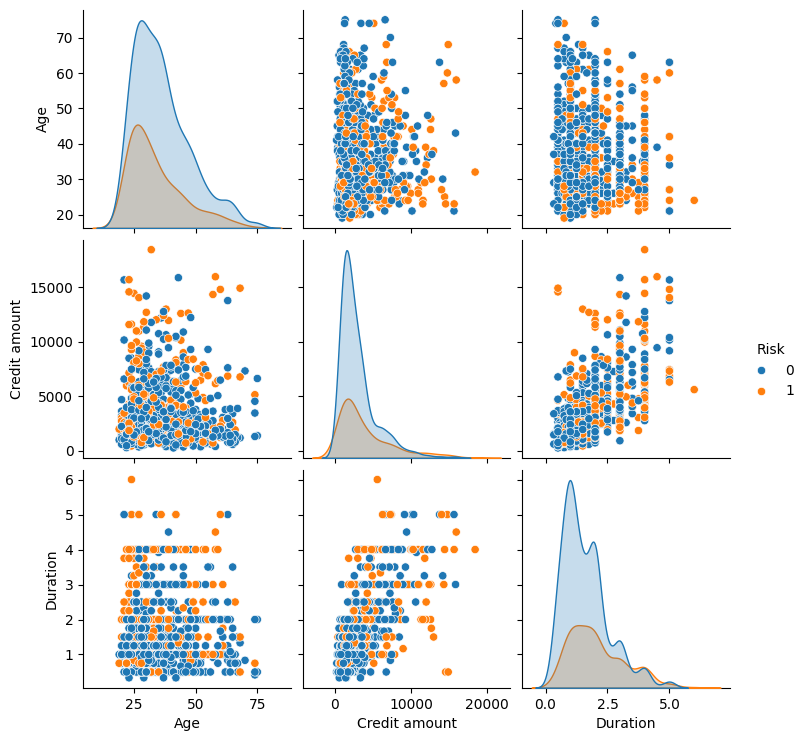

In [79]:
sns.pairplot(data, hue="Risk")
plt.show()

- There are overlaps i.e., no clear distinction in the distribution of variables for people who have defaulted and did not default.
- Let's explore this further with the help of other plots.

<Axes: >

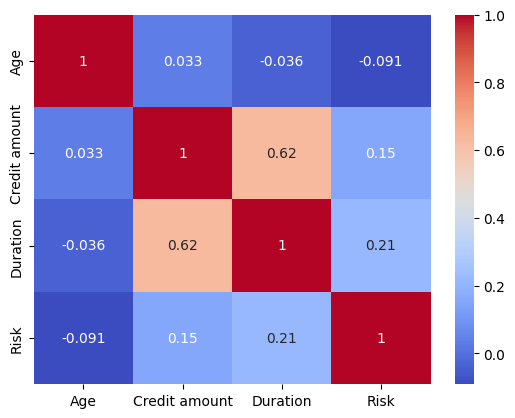

In [49]:
# Correlation Heatmap

sns.heatmap(data.corr(numeric_only=True), annot=True, cmap="coolwarm")

## **Simplified Target Comparison Plots**

<Axes: xlabel='Risk', ylabel='Credit amount'>

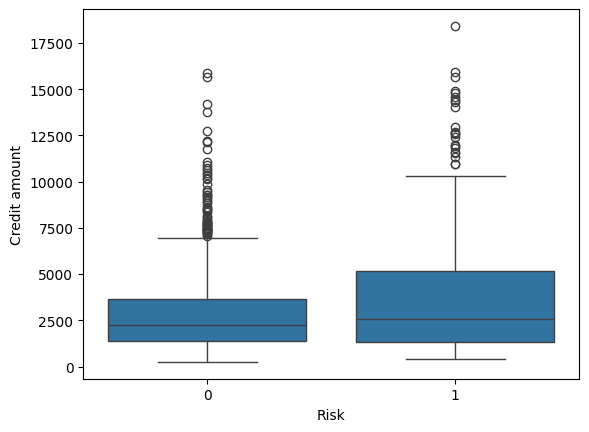

In [41]:
# Credit Amount vs Risk

sns.boxplot(data=data, x="Risk", y="Credit amount")

<Axes: xlabel='Risk', ylabel='Duration'>

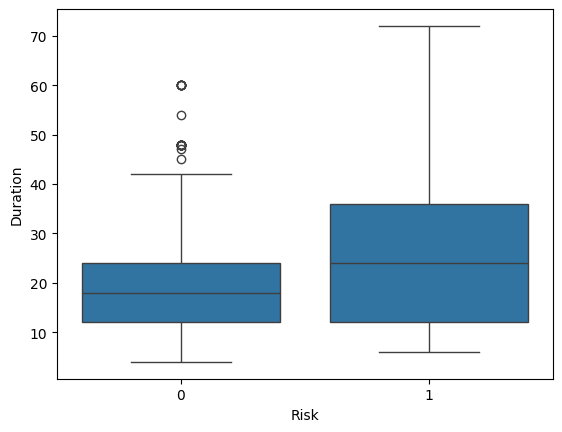

In [42]:
# Duration vs Risk

sns.boxplot(data=data, x="Risk", y="Duration")

<Axes: xlabel='Risk', ylabel='Age'>

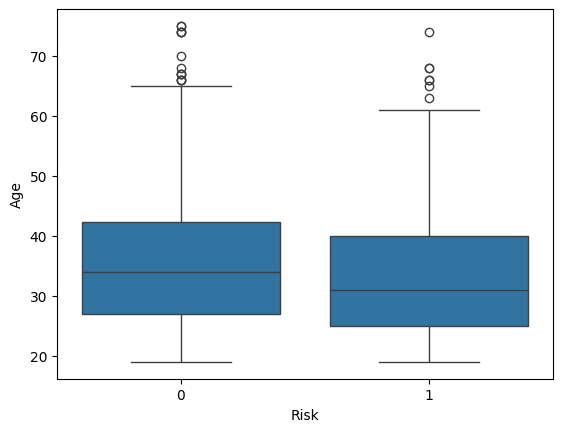

In [43]:
# Age vs Risk

sns.boxplot(data=data, x="Risk", y="Age")

([0, 1, 2, 3, 4, 5, 6, 7],
 [Text(0, 0, 'radio/TV'),
  Text(1, 0, 'education'),
  Text(2, 0, 'furniture/equipment'),
  Text(3, 0, 'car'),
  Text(4, 0, 'business'),
  Text(5, 0, 'domestic appliances'),
  Text(6, 0, 'repairs'),
  Text(7, 0, 'vacation/others')])

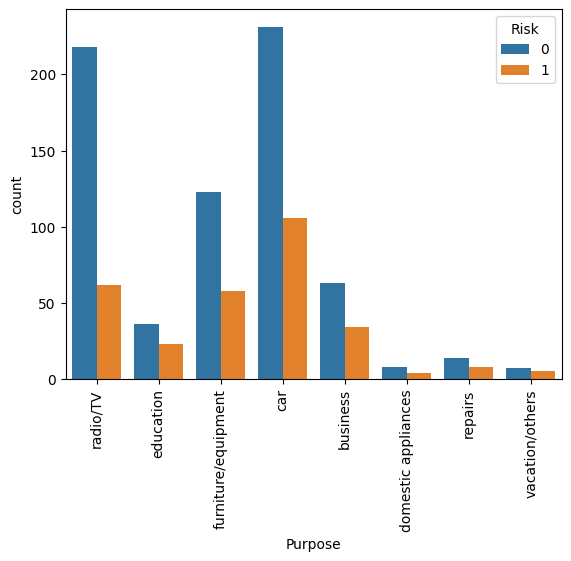

In [46]:
# Purpose vs Risk

sns.countplot(data=data, x="Purpose", hue="Risk")
plt.xticks(rotation=90)

<Axes: xlabel='Sex', ylabel='count'>

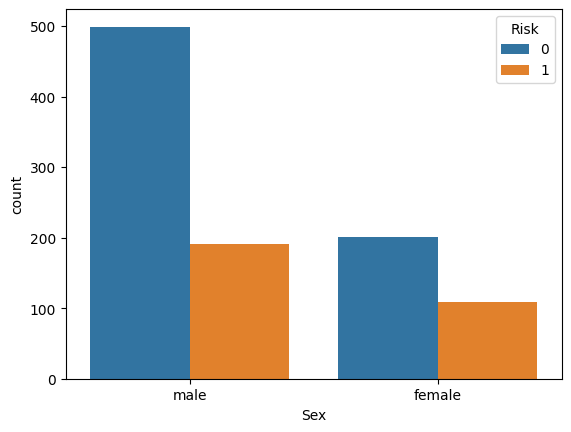

In [47]:
# Sex vs Risk

sns.countplot(data=data, x="Sex", hue="Risk")

**Observations**
- Most numerical features show weak correlations.
- Credit amount and duration may have positive correlation.
- No severe multicollinearity is observed.
- Features contribute differently to prediction.
- Heatmap helps identify feature relationships.

## **Data Preprocessing**

### Outlier Detection and Treatment

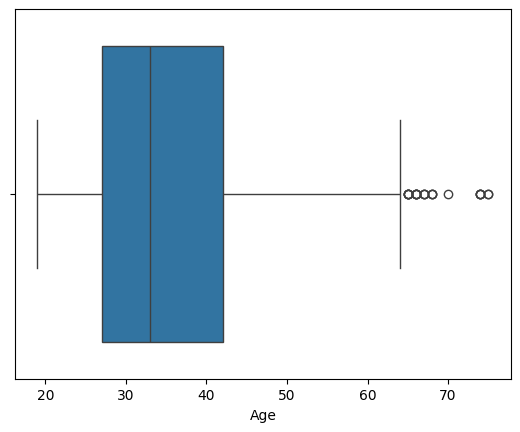

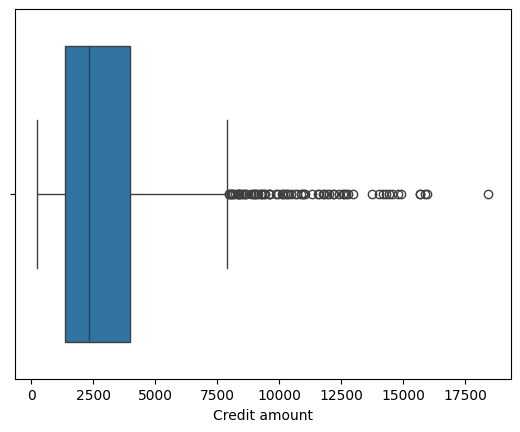

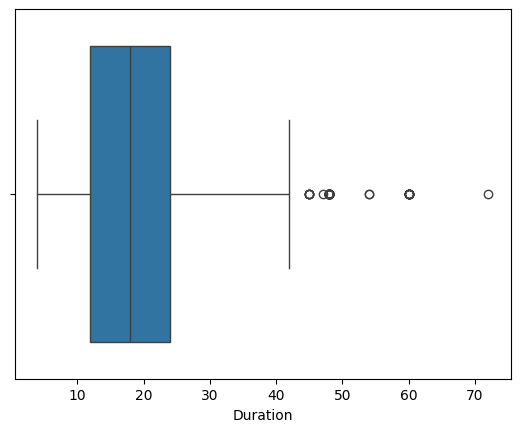

In [51]:
for col in data.select_dtypes(include=np.number).columns.drop("Risk"):
    sns.boxplot(data=data, x=col)
    plt.show()

- We will not be treating the outliers since all are genuine values.

### Data Preparation

In [52]:
# Converting monthly values to yearly
data["Duration"] = data["Duration"] / 12

In [53]:
X = data.drop("Risk", axis=1)
Y = data["Risk"]

# creating dummy variables
X = pd.get_dummies(X, drop_first=True)

# adding constant
#X = sm.add_constant(X)

# splitting in training and test set
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.3, random_state=1)#, stratify=Y)

In [54]:
print("Shape of Training set : ", X_train.shape)
print("Shape of test set : ", X_test.shape)
print("Percentage of classes in training set:")
print(y_train.value_counts(normalize=True))
print("Percentage of classes in test set:")
print(y_test.value_counts(normalize=True))

Shape of Training set :  (700, 16)
Shape of test set :  (300, 16)
Percentage of classes in training set:
Risk
0    0.694286
1    0.305714
Name: proportion, dtype: float64
Percentage of classes in test set:
Risk
0    0.713333
1    0.286667
Name: proportion, dtype: float64


## **Model Building**

### Model Evaluation Criterion

**Model can make wrong predictions as:**

1. Model predicted a non-defaulter as a defaulter - False Positive
2. Model predicted a defaulter as a non-defaulter - False Negative

**How to reduce this loss i.e need to reduce False Negatives?**

* Company would want to reduce false negatives, this can be done by maximizing the Recall. Greater the recall lesser the chances of false negatives.

First, let's create functions to calculate different metrics and confusion matrix so that we don't have to use the same code repeatedly for each model.

* The model_performance_classification_statsmodels function will be used to check the model performance of models.
* The confusion_matrix_statsmodels function will be used to plot confusion matrix.

In [62]:
log_reg = LogisticRegression()
log_reg.fit(X_train, y_train)

y_pred = (log_reg.predict_proba(X_test)[:,1] > 0.5).astype(int)

pd.DataFrame({
    "Accuracy": [accuracy_score(y_test, y_pred)],
    "Recall": [recall_score(y_test, y_pred)],
    "Precision": [precision_score(y_test, y_pred)],
    "F1 Score": [f1_score(y_test, y_pred)]
})

,Accuracy,Recall,Precision,F1 Score
0,0.723333,0.209302,0.545455,0.302521


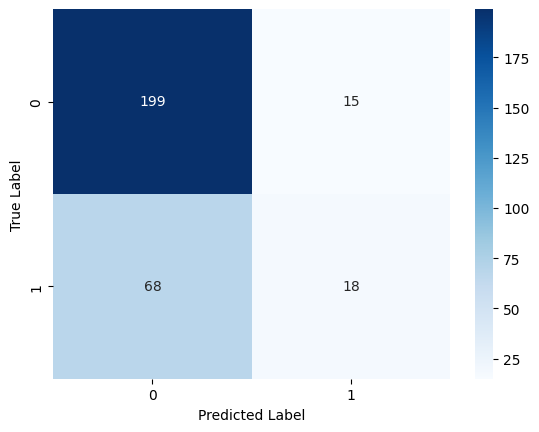

In [63]:
# Predictions
y_pred = (log_reg.predict_proba(X_test)[:,1] > 0.5).astype(int)

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

# Plot
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

In [64]:
# Fit the model on train
model = LogisticRegression(solver="newton-cg", random_state=1)
model.fit(X_train, y_train)

LogisticRegression(random_state=1, solver='newton-cg')

<Axes: >

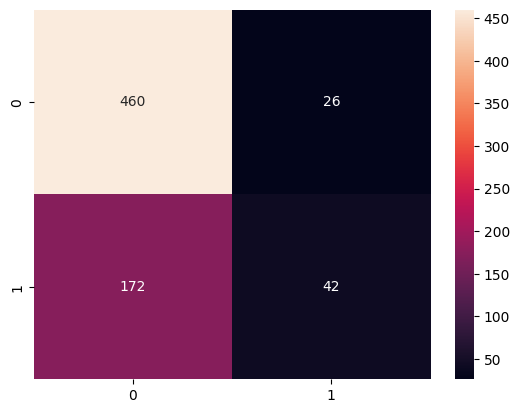

In [67]:
sns.heatmap(confusion_matrix(y_train, (log_reg.predict_proba(X_train)[:,1] > 0.5).astype(int)), annot=True, fmt="d")

In [68]:
y_pred = (log_reg.predict_proba(X_train)[:,1] > 0.5).astype(int)

pd.DataFrame({
    "Accuracy": [accuracy_score(y_train, y_pred)],
    "Recall": [recall_score(y_train, y_pred)],
    "Precision": [precision_score(y_train, y_pred)],
    "F1 Score": [f1_score(y_train, y_pred)]
})

,Accuracy,Recall,Precision,F1 Score
0,0.717143,0.196262,0.617647,0.297872


<Axes: >

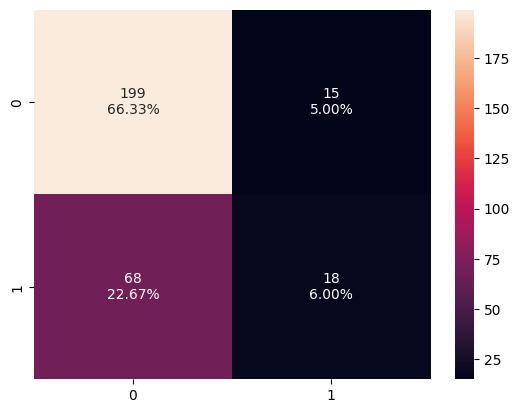

In [69]:
cm = confusion_matrix(y_test, (log_reg.predict_proba(X_test)[:,1] > 0.5).astype(int)); sns.heatmap(cm, annot=np.asarray([f"{i}\n{i/cm.sum():.2%}" for i in cm.flatten()]).reshape(2,2), fmt="")

In [70]:
y_pred = (log_reg.predict_proba(X_test)[:,1] > 0.5).astype(int)

pd.DataFrame({
    "Accuracy": [accuracy_score(y_test, y_pred)],
    "Recall": [recall_score(y_test, y_pred)],
    "Precision": [precision_score(y_test, y_pred)],
    "F1 Score": [f1_score(y_test, y_pred)]
}, index=["Test Performance"])

,Accuracy,Recall,Precision,F1 Score
Test Performance,0.723333,0.209302,0.545455,0.302521


* The model has a low recall and a low precision on the training and test sets.
* However, the training and test recalls are close enough, indicating the model is not overfitting.

## Model Performance Improvement

* Let's see if the recall score can be improved further by changing the classification threshold.
* We'll try to arrive at the optimal threshold by checking two curves:
    - ROC curve
    - Precision-Recall curve

### Optimal Threshold from ROC curve

Let's first display the ROC curve and compute the ROC-AUC score.

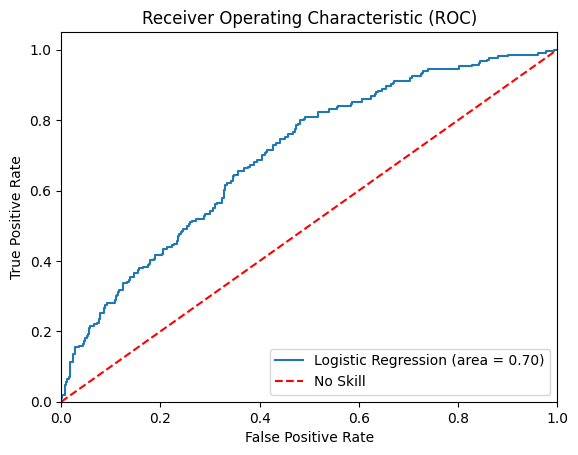

In [71]:
logit_roc_auc = roc_auc_score(y_train, model.predict_proba(X_train)[:,1])
fpr, tpr, thresholds = roc_curve(y_train, model.predict_proba(X_train)[:,1])
plt.figure()
plt.plot(fpr, tpr, label='Logistic Regression (area = %0.2f)' % logit_roc_auc)
plt.plot([0, 1], [0, 1],'r--',label='No Skill')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC)')
plt.legend(loc="lower right")
plt.show()

In [72]:
# The optimal cut off would be where tpr is high and fpr is low
optimal_idx = np.argmax(tpr - fpr)
optimal_threshold_auc_roc = thresholds[optimal_idx]
print(optimal_threshold_auc_roc)

0.25482944818295405


<Axes: >

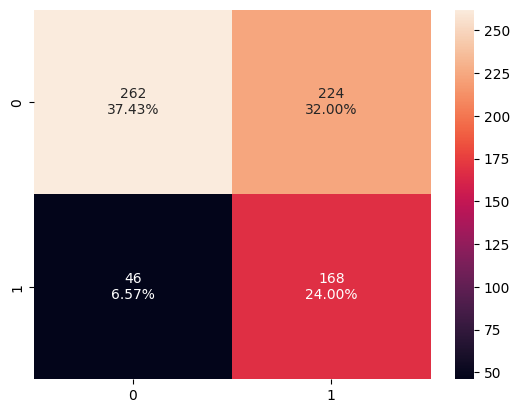

In [73]:
cm = confusion_matrix(y_train, (log_reg.predict_proba(X_train)[:,1] > optimal_threshold_auc_roc).astype(int)); sns.heatmap(cm, annot=np.asarray([f"{i}\n{i/cm.sum():.2%}" for i in cm.flatten()]).reshape(2,2), fmt="")

In [74]:
y_pred = (log_reg.predict_proba(X_train)[:,1] > optimal_threshold_auc_roc).astype(int)

pd.DataFrame({
    "Accuracy": [accuracy_score(y_train, y_pred)],
    "Recall": [recall_score(y_train, y_pred)],
    "Precision": [precision_score(y_train, y_pred)],
    "F1 Score": [f1_score(y_train, y_pred)]
}, index=["Training Performance"])

,Accuracy,Recall,Precision,F1 Score
Training Performance,0.614286,0.785047,0.428571,0.554455


<Axes: >

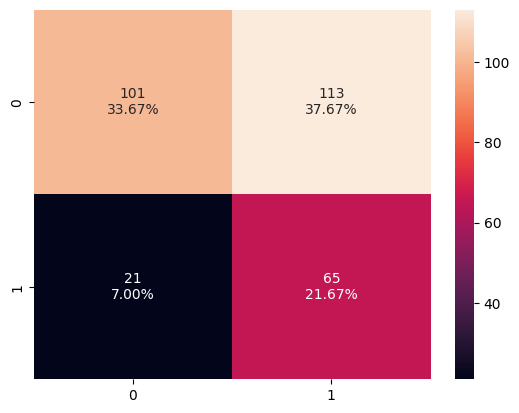

In [75]:
cm = confusion_matrix(y_test, (log_reg.predict_proba(X_test)[:,1] > optimal_threshold_auc_roc).astype(int)); sns.heatmap(cm, annot=np.asarray([f"{i}\n{i/cm.sum():.2%}" for i in cm.flatten()]).reshape(2,2), fmt="")

In [76]:
y_pred = (log_reg.predict_proba(X_test)[:,1] > optimal_threshold_auc_roc).astype(int)

pd.DataFrame({
    "Accuracy": [accuracy_score(y_test, y_pred)],
    "Recall": [recall_score(y_test, y_pred)],
    "Precision": [precision_score(y_test, y_pred)],
    "F1 Score": [f1_score(y_test, y_pred)]
}, index=["Testing Performance"])

,Accuracy,Recall,Precision,F1 Score
Testing Performance,0.553333,0.755814,0.365169,0.492424


* Model performance has improved significantly.
* Model is giving a recall of 0.74 as compared to initial model which was giving a recall of 0.2.
* Precision, however, has decreased from 0.59 to 0.35.

## Conclusions and Recommendations

- All the models are giving a generalized performance on training and test set.
- The highest recall is 79% on the training set.
- Using the model with 0.25 threshold the model will give a high recall but low precision scores - This model will help the bank identify potential customers effectively but the cost of resources will be high.
- The bank can also use the other models depending on their business goals
    - Using the model with default threshold the model will give a low recall but good precision scores - This model will help the bank save resources but lose on potential customers.
    - Using the model with 0.36 threshold the model will give a balance recall and precision score - This model will help the bank to maintain a balance in identifying potential customer and the cost of resources.

- Bank can target more male customers as they have lesser odds of defaulting.
- We saw in our analysis that customers with a little or moderate amount in saving or checking accounts are more likely to default.  The bank can be more strict with its rules or interest rates to compensate for the risk.
- Our analysis showed that younger customers are slightly more likely to default. The bank can alter its policies to deal with this.
- The observations are based on the data collected. The bank can collect more data to get a better perspective and build a more robust model.